In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import scanpy as sc
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm

In [54]:
adata = sc.read_h5ad('../data/simulation/TM_subset_cnt.h5ad')
celltype_cnts = adata.obs['cell_type'].value_counts()
celltype_cnts = celltype_cnts[celltype_cnts >= 30]

In [3]:
n_bins = 5

In [4]:
files = Path('../data/simulation/causal_simulation').rglob('tc__*.csv')
files = [str(file) for file in files]
ground_truth = {}
for file in tqdm(files, total=len(files)):
    setting = Path(file).parent.name
    runid = Path(file).stem.split('__')[1]
    ground_truth[f'{setting}__run-{runid}'] = pd.read_csv(file, header=None, index_col=None, sep='\t').iloc[0, 0]

  0%|          | 0/17000 [00:00<?, ?it/s]

In [120]:
# load icepop results
files = Path('../results/icepop_casual_mc-50').rglob('celltype__trait*.csv')
files = [str(file) for file in files]

dfs = []
for file in tqdm(files, desc="ICePop", total=len(files)):
    file = Path(file)
    setting = file.parent.name
    runid = file.stem.split("__trait-gwasz__")[1].split(".")[0]
    params = {
        k: float(v)
        for k, v in (p.split("-") for p in setting.split("__"))
    }
    df = pd.read_csv(
        file,
        usecols=["cell_type", "q"],
    )
    df["target"] = ground_truth[f"{setting}__run-{runid}"]
    df["run_idx"] = runid
    df["method"] = "ICePop"
    for k, v in params.items():
        df[k] = v
    dfs.append(df)
icepop_res_df = pd.concat(dfs, ignore_index=True)
icepop_res_df['method'] = 'ICePop'

# load seismic results
base_dir = Path("../results/seismic_casual")
files = list(base_dir.glob("*.tsv"))
dfs = []
for file in tqdm(files, desc="Seismic", total=len(files)):
    file = Path(file)
    df = pd.read_csv(
        file,
        sep="\t",
        usecols=["cell_type", "FDR"],
    ).rename(columns={"FDR": "q"})
    setting = file.stem
    params = {
        k: float(v)
        for k, v in (p.split("-") for p in setting.split("__"))
    }
    runid = str(int(params.pop("run")))
    aset = setting.split("__run-")[0]
    df["run_idx"] = runid
    df["target"] = ground_truth[f"{aset}__run-{runid}"]
    df["method"] = "Seismic"
    for k, v in params.items():
        df[k] = v
    dfs.append(df)
seismic_comb_df = pd.concat(dfs, ignore_index=True)

# # load scdrs results
# base_dir = Path("../results/scdrs_casual_downstream")
# files = list(base_dir.rglob("*.cell_type"))
# dfs = []
# for file in tqdm(files, desc="scDRS", total=len(files)):
#     file = Path(file)
#     df = pd.read_csv(
#         file,
#         sep="\t",
#         usecols=["group", "assoc_mcp"],
#     )
#     df = df.rename(columns={"group": "cell_type"})
#     df["q"] = multipletests(df["assoc_mcp"].values, method="fdr_bh")[1]
#     fname = file.name
#     setting = fname.split("__run-")[0]
#     runid = file.stem.replace(".scdrs_group", "").split("-")[-1]
#     params = {
#         k: float(v)
#         for k, v in (p.split("-") for p in setting.split("__"))
#     }
#     df["run_idx"] = runid
#     df["target"] = ground_truth[f"{setting}__run-{runid}"]
#     df["method"] = "scDRS"
#     for k, v in params.items():
#         df[k] = v
#     dfs.append(df[["cell_type", "q", "target", "run_idx"] + list(params.keys()) + ["method"]])
# scdrs_comb_df = pd.concat(dfs, ignore_index=True)

# res_df = pd.concat([icepop_res_df, seismic_comb_df, scdrs_comb_df], axis=0, ignore_index=True)
res_df = pd.concat([icepop_res_df, seismic_comb_df], axis=0, ignore_index=True)
res_df = res_df[res_df['target'] == res_df['cell_type']]
res_df['discovery'] = res_df['q'] <= 0.1

# divide into cell count bins
bins = pd.qcut(celltype_cnts, q=n_bins, labels=[f"bin_{i+1}" for i in range(n_bins)])
res_df['cell_type_cnts'] = list(celltype_cnts.loc[res_df['cell_type']])
res_df['bins'] = list(bins.loc[res_df['cell_type']])

ICePop:   0%|          | 0/17000 [00:00<?, ?it/s]

Seismic:   0%|          | 0/17000 [00:00<?, ?it/s]

In [122]:
NOISE_SD_FIXED = 1.0
BETA_FIXED = 1.0
FRAC_SIGNAL_FIXED = 0.01
SAMPLE_RATE_FIXED = 1.0

# experiment A: vary signal strength
FRAC_SIGNAL_LIST = [0.001, 0.005, 0.01, 0.05, 0.1]

# experiment B: vary noise_sd
NOISE_SD_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment C: vary beta
BETA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment D: vary cell sampling rate
SAMPLE_RATE_LIST = [0.2, 0.4, 0.6, 0.8, 1.0]

# experiment A: vary signal strength

In [131]:
def prepare_plot(res_df, vlabel='sf', bins=None):
    if vlabel == 'sf':
        a_df = res_df[
            (res_df['sf'].isin(FRAC_SIGNAL_LIST)) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'ns':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'].isin(NOISE_SD_LIST)) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'b':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'].isin(BETA_LIST)) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'sr':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'].isin(SAMPLE_RATE_LIST))
        ]
    if bins:
        a_df = a_df[a_df['bins'] == bins]
    df = (
        a_df
        .groupby([vlabel, "seed", "method"])["discovery"]
        .mean()
        .rename("power")
        .reset_index()
    )

    return df

def overall_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel='Power',
):
    df = prepare_plot(res_df, vlabel=vlabel)
    
    plt.figure(figsize=(5,3))
    
    # Bar = mean across seeds
    sns.barplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        errorbar=None,      # important: avoid double-encoding uncertainty
    )
    
    # Dots = individual seeds
    sns.stripplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        dodge=True,
        jitter=0.15,
        palette=["black", "black"],
        size=4,
        alpha=0.8,
    )
    
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(-0.03, 1.03)
    plt.title("")
    
    # remove duplicate legends (stripplot adds one)
    plt.legend().remove()
    
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    
    plt.savefig(outfile)

def split_by_ct_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel='Power', xticks_order=None
):
    fig, axs = plt.subplots(
        ncols=5, nrows=1,
        sharey=True,
        sharex=True,
        figsize=(15, 3.5),
    )

    for i in range(5):
        idx = i + 1
        cur_bin = f"bin_{idx}"
    
        df = prepare_plot(res_df, vlabel=vlabel, bins=cur_bin)

        if xticks_order is not None:
            sns.barplot(
                data=df,
                x=vlabel,
                y="power",
                hue="method",
                errorbar=None,
                ax=axs[i],
                order=xticks_order
            )
        else:
            sns.barplot(
                data=df,
                x=vlabel,
                y="power",
                hue="method",
                errorbar=None,
                ax=axs[i],
            )            
        
        sns.stripplot(
            data=df,
            x=vlabel,
            y="power",
            hue="method",
            dodge=True,
            jitter=0.15,
            palette=["black", "black"],
            size=3.5,
            clip_on=False,
            ax=axs[i],
            alpha=0.8,
        )
    
        min_cnt = celltype_cnts[bins[bins == cur_bin].index].min()
        max_cnt = celltype_cnts[bins[bins == cur_bin].index].max()
    
        axs[i].set_xlabel("")
        if i == 0:
            axs[i].set_ylabel(ylabel, fontsize=14)
        else:
            axs[i].set_ylabel("")
    
        axs[i].set_ylim(-0.03, 1.03)
    
        title_bin = cur_bin.replace("_", " ")
        axs[i].set_title(
            f"Cell type {title_bin}: {min_cnt:,}-{max_cnt:,}"
        )

        axs[i].tick_params(axis="x", labelsize=12)
        axs[i].tick_params(axis="y", labelsize=12)
    
        axs[i].legend().remove()
        axs[i].spines["top"].set_visible(False)
        axs[i].spines["right"].set_visible(False)
    
    fig.subplots_adjust(
        left=0.04,    # reduce left margin
        right=0.995,  # reduce right margin
        bottom=0.18,  # space for xlabel
        top=0.88,     # space for titles
        wspace=0.15   # less space between panels
    )
    fig.supxlabel(xlabel, fontsize=14)
    
    plt.savefig(outfile, bbox_inches="tight")

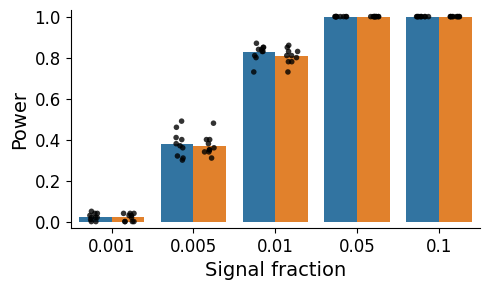

In [132]:
vlabel = 'sf'
overall_perf(
    res_df, vlabel,
    "../paper/main/causal_sf.pdf",
    xlabel="Signal fraction",
    ylabel='Power'
)

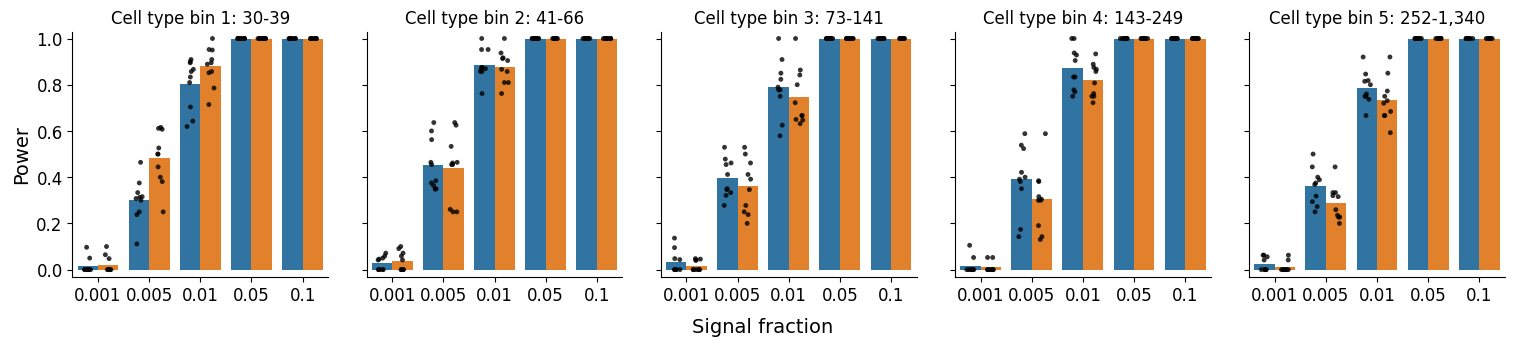

In [133]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_sf_ctsize.pdf",
    xlabel="Signal fraction",
    ylabel='Power'
)

# experiment B: vary noise_sd

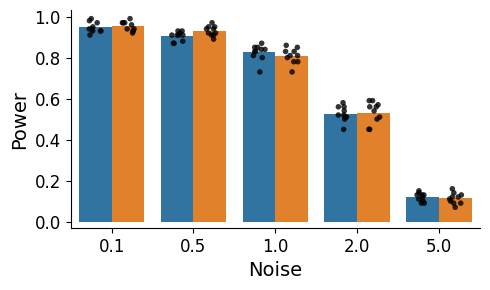

In [126]:
vlabel = 'ns'
overall_perf(
    res_df, vlabel, "../paper/main/causal_ns.pdf",
    xlabel="Noise",
    ylabel='Power',
)

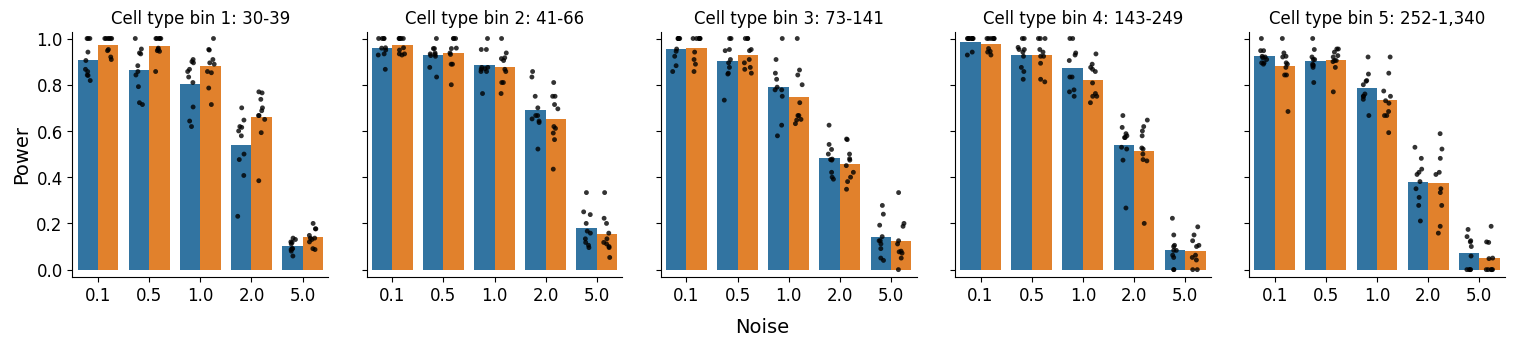

In [127]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_ns_ctsize.pdf",
    xlabel="Noise",
    ylabel='Power'
)

# experiment C: vary beta

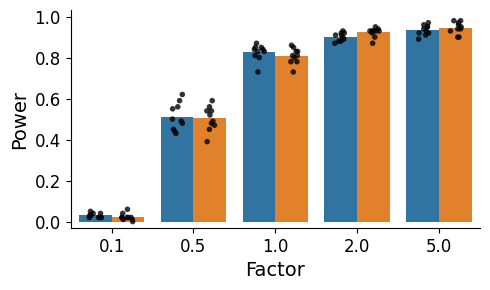

In [117]:
vlabel = 'b'
overall_perf(
    res_df, vlabel, "../paper/main/causal_factor.pdf",
    xlabel="Factor",
    ylabel='Power',
)

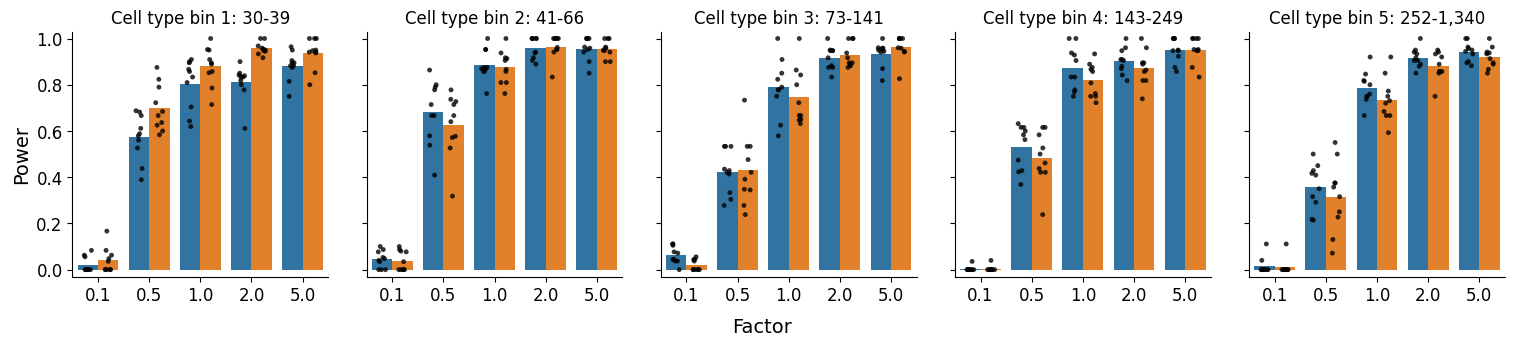

In [118]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_factor_ctsize.pdf",
    xlabel="Factor",
    ylabel='Power'
)

# experiment D: vary sample rate

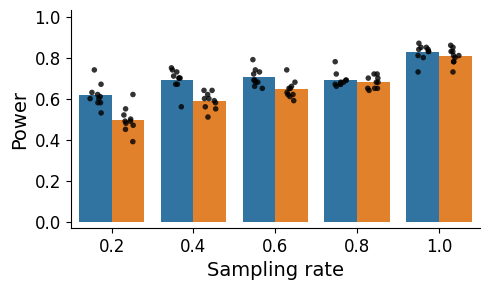

In [115]:
vlabel = 'sr'
overall_perf(
    res_df, vlabel, "../paper/main/causal_sr.pdf",
    xlabel="Sampling rate",
    ylabel='Power',
)

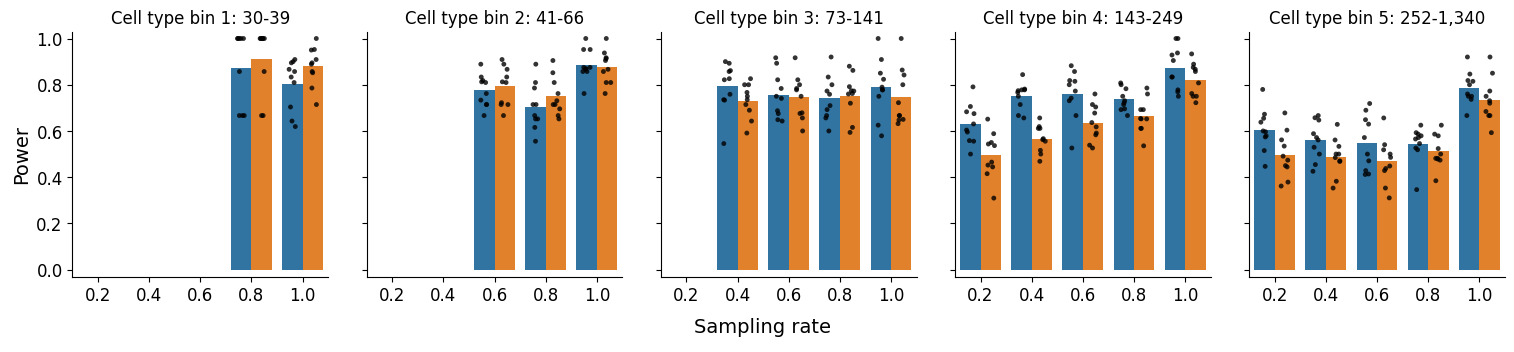

In [116]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_sr_ctsize.pdf",
    xlabel="Sampling rate",
    ylabel='Power',
    xticks_order=[0.2, 0.4, 0.6, 0.8, 1.0]
)